<a href="https://colab.research.google.com/github/DaniloDuque/multimodal-cataract-seg/blob/main/src/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/DaniloDuque/multimodal-cataract-seg/blob/main/src/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Modal Attention Fusion for Anterior Segment Segmentation

This notebook orchestrates all experiments for the paper. It runs four models:

| Model | Description |
|-------|-------------|
| U-Net (RGB) | Standard baseline, RGB input only |
| U-Net (Edge) | Edge map input only |
| U-Net (Early Fusion) | RGB + Edge concatenated at input |
| **Proposed** | Dual encoder + bottleneck cross-attention |

Metrics reported: **IoU** (primary), Dice, F1.

---
## Environment Setup

Clones the repository if running in Colab, pulls latest changes if it already exists, and adds `src/` to the Python path.

In [5]:
## @brief Sets up the execution environment (Colab or local).
#  Clones the repository on first run; pulls latest changes on subsequent runs.
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('multimodal-cataract-seg'):
        os.system('git clone https://github.com/DaniloDuque/multimodal-cataract-seg')
    else:
        os.system('git -C multimodal-cataract-seg pull')
    os.chdir('multimodal-cataract-seg/src')

if 'src' not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

## Dependencies

In [6]:
## @brief Installs all project dependencies.
import subprocess, sys

deps = [
    'torch', 'torchvision',
    'segmentation-models-pytorch',
    'torchmetrics',
    'opencv-python',
    'albumentations',
    'roboflow',
    'python-dotenv',
    'matplotlib',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + deps, check=True)
print('✓ Dependencies installed.')

✓ Dependencies installed.


## Imports and Configuration

In [7]:
## @brief Imports all project modules and sets the random seed for reproducibility.
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

from config import CONFIG
from data.dataset import CataractSegDataset
from models.unet_baseline import UNetBaseline
from models.dual_encoder import DualEncoderUNet
from train import train
from evaluate import compute_metrics, print_results_table

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
Path(CONFIG['checkpoints_dir']).mkdir(exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(exist_ok=True)

print(f"Device: {CONFIG['device']}")

Device: cuda


---
## Dataset Download

Downloads the Cataract-Seg dataset from Roboflow using the API key stored in `.env`.
Set `RF_API_KEY` in your `.env` file before running.

In [8]:
## @brief Downloads the Cataract-Seg dataset from Roboflow in PNG masks format.
#  In Colab: reads RF_API_KEY from Colab Secrets (left sidebar → key icon).
#  Locally: reads RF_API_KEY from the .env file at the project root.
import os
from dotenv import load_dotenv
from roboflow import Roboflow

if 'google.colab' in sys.modules:
    from google.colab import userdata
    api_key = userdata.get('RF_API_KEY')
else:
    load_dotenv(dotenv_path=os.path.join('..', '.env'))
    api_key = os.environ.get('RF_API_KEY', '')

assert api_key, 'RF_API_KEY not found. Add it to Colab Secrets or your .env file.'

rf      = Roboflow(api_key=api_key)
project = rf.workspace('muhammad-risma').project('cataract-seg')
dataset = project.version(1).download('coco-segmentation', location=CONFIG['data_root'])
print(f"✓ Dataset downloaded to {CONFIG['data_root']}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/cataract-seg in coco-segmentation:: 100%|██████████| 307/307 [00:00<00:00, 7679.86it/s]

✓ Dataset downloaded to data/cataract-seg


---
## Data Loading

Builds train/valid/test datasets and dataloaders. All models share the same loaders for a fair comparison.

In [9]:
## @brief Builds train, valid, and test DataLoaders.
def make_loader(split, shuffle):
    ds = CataractSegDataset(
        data_root=CONFIG['data_root'],
        split=split,
        img_size=CONFIG['img_size'],
        canny_t1=CONFIG['canny_t1'],
        canny_t2=CONFIG['canny_t2'],
    )
    return DataLoader(ds, batch_size=CONFIG['batch_size'], shuffle=shuffle, num_workers=2)

train_loader = make_loader('train', shuffle=True)
val_loader   = make_loader('valid', shuffle=False)
test_loader  = make_loader('test',  shuffle=False)

print(f"Train: {len(train_loader.dataset)} | "
      f"Valid: {len(val_loader.dataset)} | "
      f"Test:  {len(test_loader.dataset)}")

Train: 210 | Valid: 59 | Test:  30


---
## Model Training

Four independent training runs. Each saves its best checkpoint (by validation loss) to `checkpoints/`.

In [10]:
## @brief Trains the U-Net (RGB) baseline.
model_rgb = UNetBaseline(in_channels=3).to(CONFIG['device'])
history_rgb = train(model_rgb, train_loader, val_loader, CONFIG, mode='rgb', run_name='unet_rgb')
print('✓ U-Net (RGB) trained.')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[unet_rgb] Epoch 10/100  train=0.4457  val=0.4237  val_iou=0.9414
[unet_rgb] Epoch 20/100  train=0.2229  val=0.2268  val_iou=0.9391
[unet_rgb] Epoch 30/100  train=0.1296  val=0.1348  val_iou=0.9516
[unet_rgb] Epoch 40/100  train=0.0891  val=0.1038  val_iou=0.9464
[unet_rgb] Epoch 50/100  train=0.0652  val=0.0945  val_iou=0.9411
[unet_rgb] Epoch 60/100  train=0.0765  val=0.0766  val_iou=0.9508
[unet_rgb] Epoch 70/100  train=0.0473  val=0.0671  val_iou=0.9504
[unet_rgb] Epoch 80/100  train=0.0441  val=0.0628  val_iou=0.9498
[unet_rgb] Epoch 90/100  train=0.0327  val=0.0650  val_iou=0.9489
[unet_rgb] Epoch 100/100  train=0.0295  val=0.0743  val_iou=0.9427
✓ U-Net (RGB) trained.


In [11]:
## @brief Trains the U-Net (Edge) baseline using only the Canny edge map as input.
model_edge = UNetBaseline(in_channels=3).to(CONFIG['device'])
history_edge = train(model_edge, train_loader, val_loader, CONFIG, mode='edge', run_name='unet_edge')
print('✓ U-Net (Edge) trained.')

[unet_edge] Epoch 10/100  train=0.4127  val=0.4405  val_iou=0.7281
[unet_edge] Epoch 20/100  train=0.2586  val=0.3111  val_iou=0.7660
[unet_edge] Epoch 30/100  train=0.1939  val=0.2334  val_iou=0.8114
[unet_edge] Epoch 40/100  train=0.1444  val=0.1756  val_iou=0.8496
[unet_edge] Epoch 50/100  train=0.1356  val=0.1512  val_iou=0.8681
[unet_edge] Epoch 60/100  train=0.1171  val=0.1507  val_iou=0.8627
[unet_edge] Epoch 70/100  train=0.0979  val=0.1329  val_iou=0.8778
[unet_edge] Epoch 80/100  train=0.0987  val=0.1416  val_iou=0.8727
[unet_edge] Epoch 90/100  train=0.0838  val=0.1113  val_iou=0.8992
[unet_edge] Epoch 100/100  train=0.0747  val=0.1109  val_iou=0.8977
✓ U-Net (Edge) trained.


In [12]:
## @brief Trains the early-fusion baseline (RGB + Edge concatenated at the input channel).
model_ef = UNetBaseline(in_channels=6).to(CONFIG['device'])
history_ef = train(model_ef, train_loader, val_loader, CONFIG, mode='early_fusion', run_name='unet_early_fusion')
print('✓ U-Net (Early Fusion) trained.')

[unet_early_fusion] Epoch 10/100  train=0.3832  val=0.3507  val_iou=0.9424
[unet_early_fusion] Epoch 20/100  train=0.1778  val=0.1720  val_iou=0.9463
[unet_early_fusion] Epoch 30/100  train=0.1121  val=0.1123  val_iou=0.9476
[unet_early_fusion] Epoch 40/100  train=0.0824  val=0.0928  val_iou=0.9428
[unet_early_fusion] Epoch 50/100  train=0.0693  val=0.0692  val_iou=0.9537
[unet_early_fusion] Epoch 60/100  train=0.0486  val=0.0670  val_iou=0.9520
[unet_early_fusion] Epoch 70/100  train=0.0444  val=0.0597  val_iou=0.9537
[unet_early_fusion] Epoch 80/100  train=0.0448  val=0.0568  val_iou=0.9538
[unet_early_fusion] Epoch 90/100  train=0.0372  val=0.0585  val_iou=0.9528
[unet_early_fusion] Epoch 100/100  train=0.0438  val=0.0559  val_iou=0.9536
✓ U-Net (Early Fusion) trained.


In [13]:
## @brief Trains the proposed dual-encoder model with bottleneck cross-attention fusion.
model_dual = DualEncoderUNet(
    num_classes=1,
    embed_dim=CONFIG['embed_dim'],
    num_heads=CONFIG['n_heads'],
).to(CONFIG['device'])
history_dual = train(model_dual, train_loader, val_loader, CONFIG, mode='dual', run_name='dual_encoder')
print('✓ Dual Encoder (Proposed) trained.')

[dual_encoder] Epoch 10/100  train=0.4669  val=0.4572  val_iou=0.9217
[dual_encoder] Epoch 20/100  train=0.2446  val=0.2322  val_iou=0.9449
[dual_encoder] Epoch 30/100  train=0.1660  val=0.1439  val_iou=0.9458
[dual_encoder] Epoch 40/100  train=0.0930  val=0.1073  val_iou=0.9477
[dual_encoder] Epoch 50/100  train=0.0716  val=0.0824  val_iou=0.9539
[dual_encoder] Epoch 60/100  train=0.0632  val=0.0790  val_iou=0.9468
[dual_encoder] Epoch 70/100  train=0.0473  val=0.0676  val_iou=0.9501
[dual_encoder] Epoch 80/100  train=0.0379  val=0.0642  val_iou=0.9505
[dual_encoder] Epoch 90/100  train=0.0342  val=0.0549  val_iou=0.9570
[dual_encoder] Epoch 100/100  train=0.0346  val=0.0538  val_iou=0.9553
✓ Dual Encoder (Proposed) trained.


---
## Training Curves

Loss curves (BCE + Dice) for all models over the full training run.

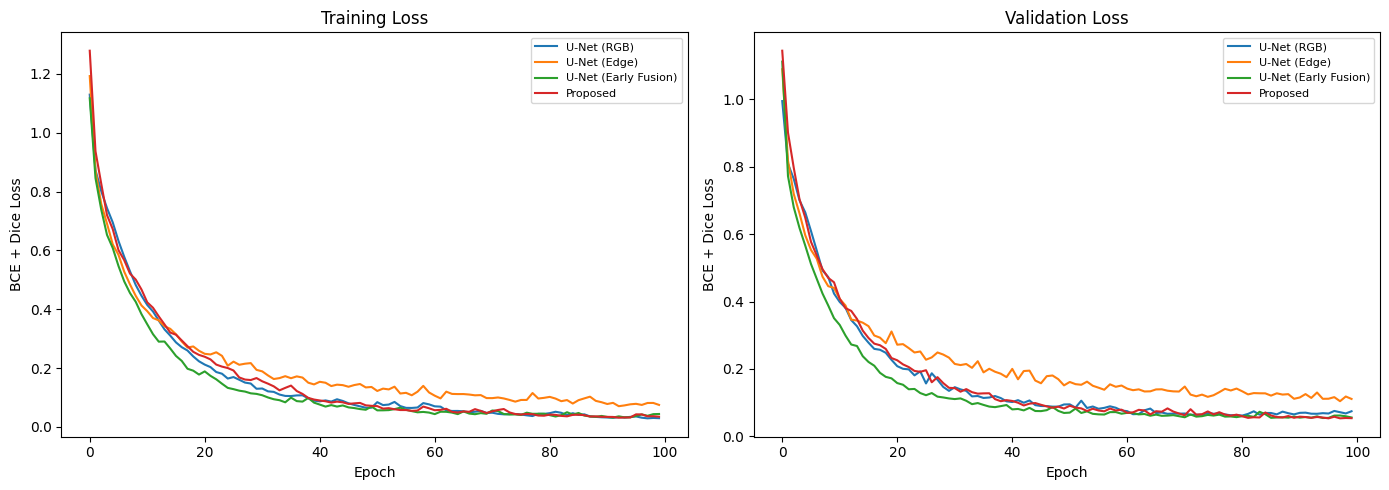

In [14]:
## @brief Plots training and validation loss curves for all four models.
histories = {
    'U-Net (RGB)':          history_rgb,
    'U-Net (Edge)':         history_edge,
    'U-Net (Early Fusion)': history_ef,
    'Proposed':             history_dual,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h['train_losses'], label=name)
    axes[1].plot(h['val_losses'],   label=name)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE + Dice Loss')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/loss_curves.pdf", bbox_inches='tight')
plt.show()

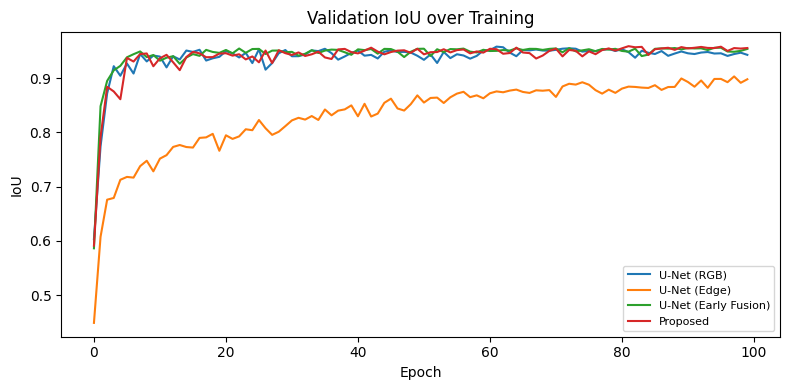

In [15]:
## @brief Plots validation IoU curves for all four models over training.
fig, ax = plt.subplots(figsize=(8, 4))
for name, h in histories.items():
    ax.plot(h["val_ious"], label=name)
ax.set_title("Validation IoU over Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("IoU")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/val_iou_curves.pdf", bbox_inches="tight")
plt.show()

---
## Test Set Evaluation

Loads the best checkpoint for each model and evaluates on the held-out test set.

In [16]:
## @brief Loads best checkpoints and computes IoU, Dice, and F1 on the test set.
runs = [
    ('U-Net (RGB)',          model_rgb,  'unet_rgb',          'rgb'),
    ('U-Net (Edge)',         model_edge, 'unet_edge',         'edge'),
    ('U-Net (Early Fusion)', model_ef,   'unet_early_fusion', 'early_fusion'),
    ('Proposed',             model_dual, 'dual_encoder',      'dual'),
]

results = {}
for name, model, ckpt_name, mode in runs:
    ckpt = os.path.join(CONFIG['checkpoints_dir'], f'{ckpt_name}_best.pth')
    model.load_state_dict(torch.load(ckpt, map_location=CONFIG['device']))
    results[name] = compute_metrics(model, test_loader, CONFIG, mode)

print_results_table(results)


Model                    IoU      Dice        F1
U-Net (RGB)           0.9501    0.9747    0.9744
U-Net (Edge)          0.8891    0.9409    0.9413
U-Net (Early Fusion)    0.9514    0.9753    0.9751
Proposed              0.9498    0.9745    0.9743


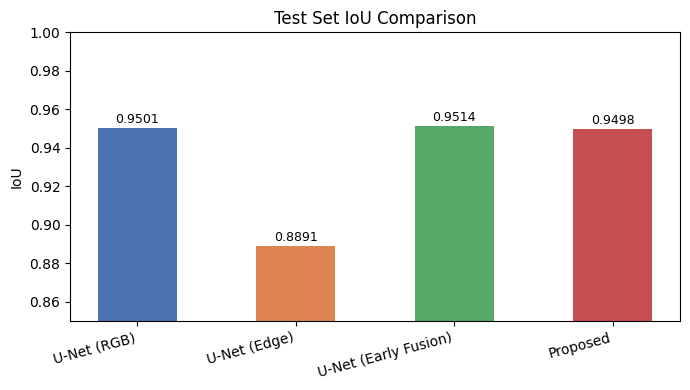

In [19]:
## @brief Bar chart comparing IoU across all four models.
models = list(results.keys())
iou_vals = [results[m]["iou"] for m in models]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, iou_vals, color=colors, width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("IoU")
ax.set_title("Test Set IoU Comparison")
for bar, val in zip(bars, iou_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/iou_comparison.pdf", bbox_inches="tight")
plt.show()

---
## Qualitative Predictions

Visual comparison of predicted masks for a sample batch from the test set.

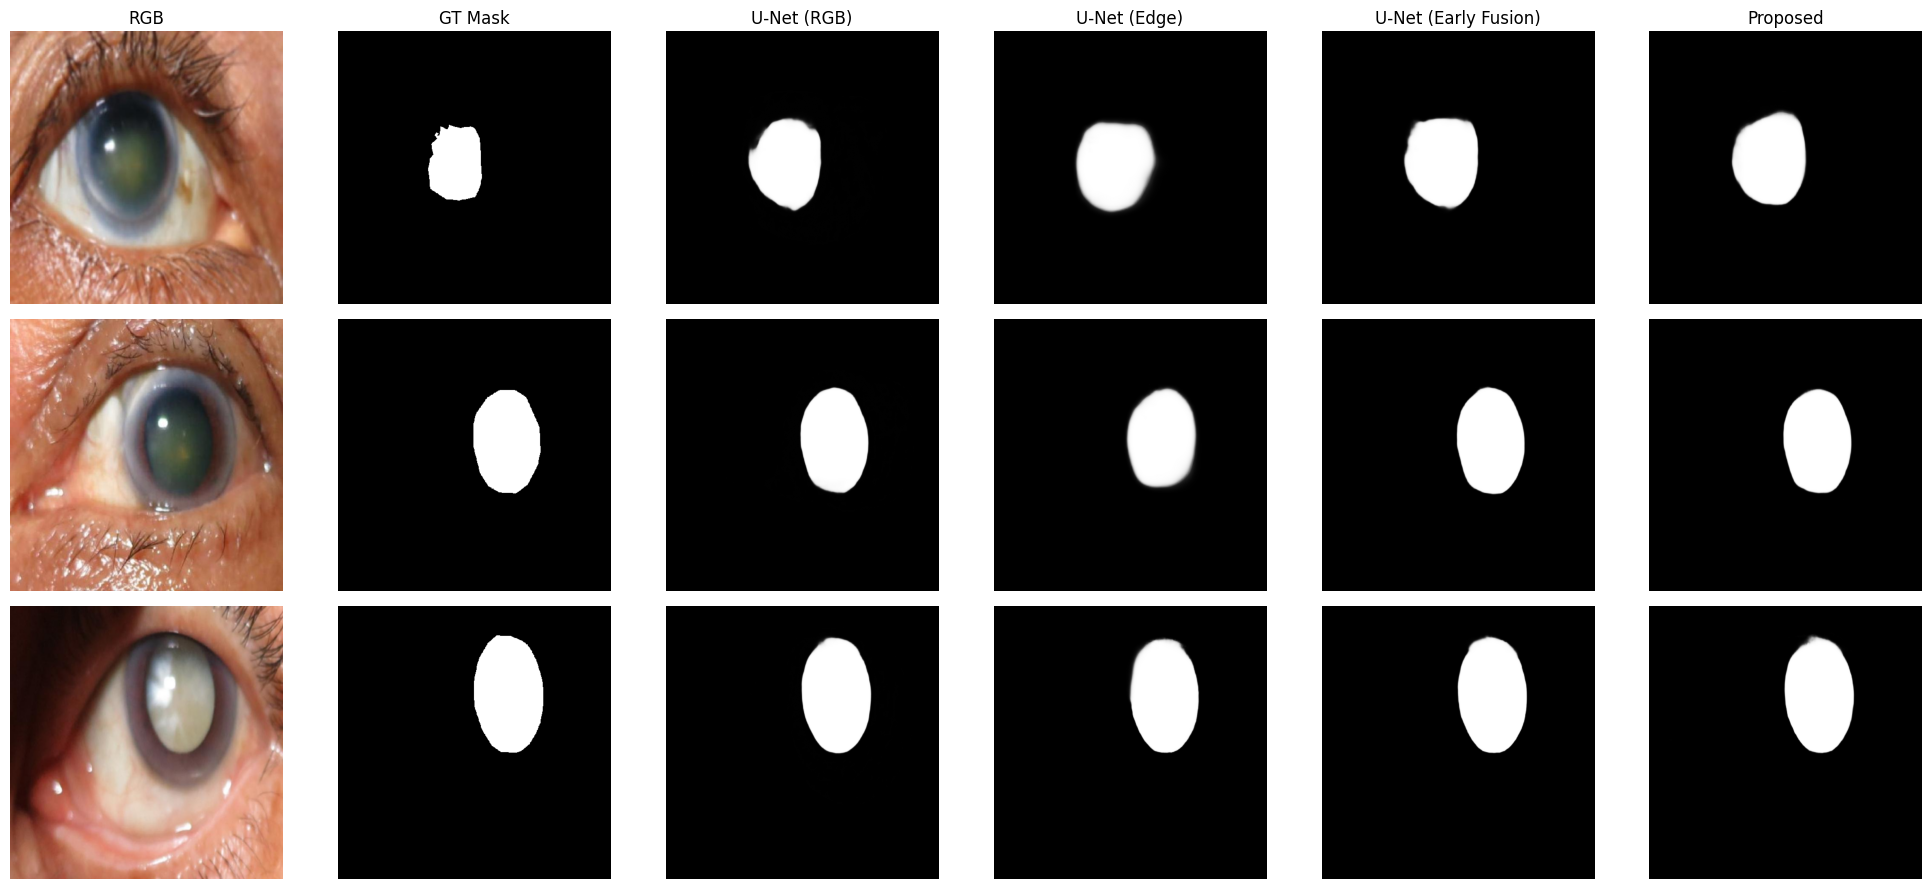

In [22]:
## @brief Visualizes predicted masks from all four models on three test images.
from train import _forward

rgb_batch, edge_batch, mask_batch = next(iter(test_loader))
rgb_batch  = rgb_batch[:3].to(CONFIG['device'])
edge_batch = edge_batch[:3].to(CONFIG['device'])
mask_batch = mask_batch[:3]

model_names = ['U-Net (RGB)', 'U-Net (Edge)', 'U-Net (Early Fusion)', 'Proposed']
mode_map    = {'U-Net (RGB)': 'rgb', 'U-Net (Edge)': 'edge',
               'U-Net (Early Fusion)': 'early_fusion', 'Proposed': 'dual'}
model_map   = {'U-Net (RGB)': model_rgb, 'U-Net (Edge)': model_edge,
               'U-Net (Early Fusion)': model_ef, 'Proposed': model_dual}

n_imgs = 3
fig, axes = plt.subplots(n_imgs, len(model_names) + 2, figsize=(20, 3 * n_imgs))

for i in range(n_imgs):
    axes[i, 0].imshow(rgb_batch[i].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i, 0].set_title('RGB' if i == 0 else '')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_batch[i, 0], cmap='gray')
    axes[i, 1].set_title('GT Mask' if i == 0 else '')
    axes[i, 1].axis('off')
    for j, name in enumerate(model_names):
        with torch.no_grad():
            pred = torch.sigmoid(_forward(model_map[name], rgb_batch[[i]], edge_batch[[i]], mode_map[name]))
        axes[i, j + 2].imshow(pred[0, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[i, j + 2].set_title(name if i == 0 else '')
        axes[i, j + 2].axis('off')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/qualitative_predictions.pdf", bbox_inches='tight')
plt.show()